In [1]:
"""
mo_extract_dar_outputs.ipynb

This script is to extract the identified DARs from pycistopic

authors: Roy Oelen
"""

'\nmo_extract_dar_outputs.ipynb\n\nThis script is to extract the identified DARs from pycistopic\n\nauthors: Roy Oelen\n'

In [2]:
###########
# imports #
###########

# for path operations
import os
import glob
from pathlib import Path
# for the pycistopic object and methods
import pycisTopic
# for working with tables
import pandas as pd
# sparse matrix operations in pycistopic
from scipy import sparse, io
# methods used for dar detection
from pycisTopic.diff_features import (
    impute_accessibility,
    normalize_scores,
    find_highly_variable_features,
    find_diff_features
)
# quicker numpy operations
import numpy as np
# for storing the result
import joblib
# for making the md5
import hashlib
# for making plots
import seaborn as sns
import matplotlib.pyplot as plt
# to convert the region names back into the format of a bed
from pycisTopic.utils import region_names_to_coordinates
# and for plotting the overlap
from upsetplot import plot
from matplotlib import pyplot
from upsetplot import from_contents
from upsetplot import UpSet
# set size of figures
from matplotlib.pyplot import figure


/home/umcg-roelen/miniconda3/envs/pycistopic_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-11 15:56:04,743	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
#############
# functions #
#############

# method to create md5
def create_md5_file(input_file):
    """
    Creates an MD5 hash of the specified file and writes it to a new file with the same name but .md5 added to the extension.

    Args:
        input_file (str): The path to the input file for which the MD5 hash should be created.

    Returns:
        int: Returns 0 on success, 1 on failure.

    Raises:
        FileNotFoundError: Thrown if the input file does not exist.
        IOError: Thrown if there is an error reading the input file (like permission denied) or writing the output md5 file.
    """
    try:
        # get an md5 of the file
        digest = None
        with open(input_file, "rb") as f:
            # try Python 3.11+ method if it is available
            if callable(getattr(hashlib, 'file_digest', None)):
                # digest with one command
                digest = hashlib.file_digest(f, 'md5')
            # or the older 3.8+ method if we don't have the newer method
            else:
                # initialize digest
                digest = hashlib.md5()
                # read file in chunks
                while chunk := f.read(8192):
                    # update digestion
                    digest.update(chunk)       
        # get the output path of the md5
        output_md5_loc = ''.join([input_file, '.md5'])
        # and write that
        with open(output_md5_loc, "w") as m:
            m.write(digest.hexdigest())
        # upon success, return 0
        return 0
    except Exception as e:
        print(f"Exception occured upon md5 file creation: {e}")
        return 1


In [4]:
####################
# read DARS object #
####################

# location of the DARs we identified
dars_object_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/dar_detection/merged_major_and_minor_celltypes_120topics/wilcoxon/merged_major_and_minor_celltypes_120topics_dars.joblib'
# load those results
dars_dict = joblib.load(dars_object_loc)


In [5]:
#########################
# convert DARs to table #
#########################

# add the region as an explicit column
for topic, topic_df in dars_dict.items():
    # extract the df and add the region as an explicit column
    topic_df = pd.concat([pd.DataFrame({'region' : topic_df.index}, index = topic_df.index), topic_df], axis = 1)
    # put back in the list
    dars_dict[topic] = topic_df


In [6]:
# now merge all of the tables together
dars_table = pd.concat(dars_dict.values(), ignore_index=True)


In [7]:
# write this as a table
dars_table_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/dar_detection/merged_major_and_minor_celltypes_120topics/wilcoxon/merged_major_and_minor_celltypes_120topics_dars.tsv.gz'
dars_table.to_csv(dars_table_loc, sep = '\t', index = False, header = True, compression = 'gzip')
# and create a checksum
create_md5_file(dars_table_loc)


0

In [8]:
# check now may rows are in the table
total_dar_topic_combinations = dars_table.shape[0]
# check now may are significant
total_dar_topic_combinations_significant = dars_table[dars_table[['Adjusted_pval']] < 0.05].shape[0]
# print this
print(' '.join(['out of', str(total_dar_topic_combinations), 'DAR-topic combinations,', str(total_dar_topic_combinations_significant), 'are significant']))


out of 5391020 DAR-topic combinations, 5391020 are significant


In [9]:
##############################
# filter to significant DARs #
##############################

# just subset to the significant ones (even though that is not necessary)
dars_table = dars_table[dars_table['Adjusted_pval'] < 0.05]


In [10]:
############################
# DAR and topic statistics #
############################

# get the number of DARs per topic
dars_per_topic = pd.DataFrame(dars_table['Contrast'].value_counts())
# get the number of DARs per region
dars_per_region = pd.DataFrame(dars_table['region'].value_counts())


In [11]:
# add the topic as explicit column in the dars per topic
dars_per_topic['Topic'] = dars_per_topic.index
# and rename 'Contrast'
dars_per_topic = dars_per_topic.rename({'Contrast' : 'n_dar'}, axis = 1)
# and repeat for the region one as well
dars_per_region = dars_per_region.rename({'region' : 'n_topic'}, axis = 1)
dars_per_region['region'] = dars_per_region.index


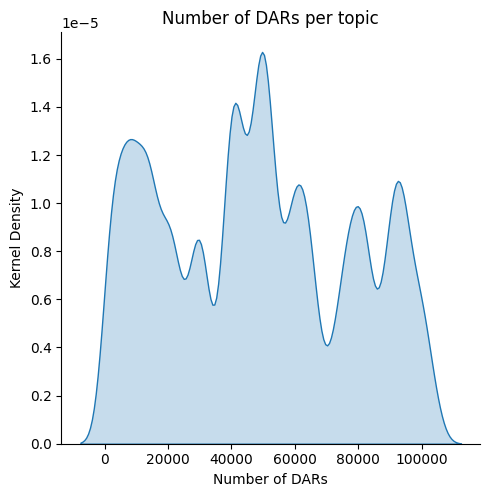

In [12]:
# plot the density of the dars per topic
ax = sns.displot(dars_per_topic, x="n_dar", kind="kde", bw_adjust=.25, fill = True)
# with nicer labels
ax.set(xlabel='Number of DARs', ylabel='Kernel Density', title = 'Number of DARs per topic')
plt.show()


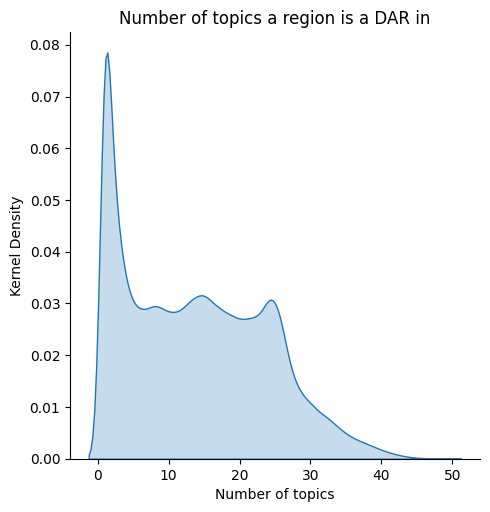

In [13]:
# plot the density of the topic DARs per region
ax = sns.displot(dars_per_region, x="n_topic", kind="kde", fill = True)
# with nicer labels
ax.set(xlabel='Number of topics', ylabel='Kernel Density', title = 'Number of topics a region is a DAR in')
plt.show()


In [14]:
# they should already be sorted, but let's do it anyway
dars_per_topic = dars_per_topic.sort_values(by = ['n_dar'], ascending = False)
dars_per_region = dars_per_region.sort_values(by = ['n_topic'], ascending = False)
# and add the rank as a column
dars_per_topic['topic_rank'] = np.arange(dars_per_topic.shape[0])
dars_per_region['region_rank'] = np.arange(dars_per_region.shape[0])


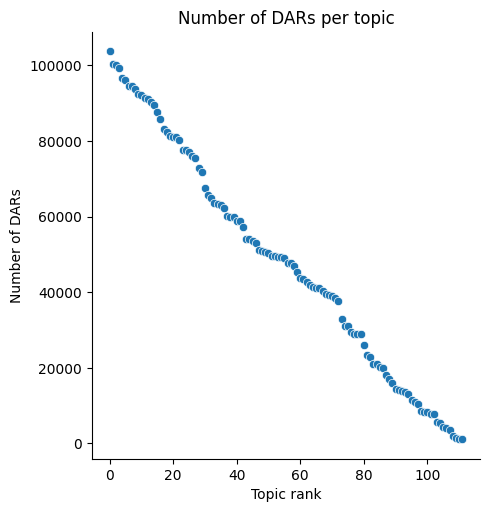

In [15]:
# and plot the rank vs the number of DARs
ax = sns.relplot(data = dars_per_topic, x = "topic_rank", y = "n_dar")
# with nicer labels
ax.set(xlabel='Topic rank', ylabel='Number of DARs', title = 'Number of DARs per topic')
plt.show()


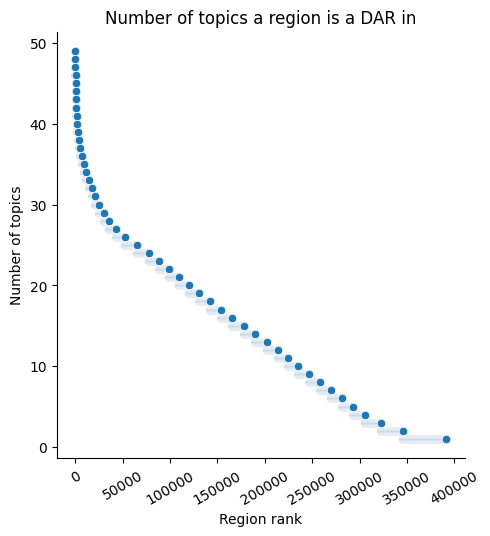

In [16]:
# and plot the rank of the region vs the number topics it is a DAR in
ax = sns.relplot(data = dars_per_region, x = "region_rank", y = "n_topic")
# with nicer labels
ax.set(xlabel='Region rank', ylabel='Number of topics', title = 'Number of topics a region is a DAR in')
# and because the numbers are large, let's angle the x ticks a bit
plt.xticks(rotation=30)
plt.show()

In [17]:
# where to put the beds
beds_folder = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/dar_detection/merged_major_and_minor_celltypes_120topics/wilcoxon/beds/'
# check each of the topics
different_topics = dars_table['Contrast'].unique()
for topic in different_topics:
    # subset to that topic
    dars_table_topic = dars_table[dars_table['Contrast'] == topic]
    # extract the region
    dars_topic = dars_table_topic['region']
    # paste together the full path
    dars_topic_bed = ''.join([beds_folder, '/', topic, '.bed'])
    # make into regions
    dars_topic_regions = region_names_to_coordinates(
        dars_topic
    ).sort_values(
        ['Chromosome', 'Start', 'End']
    )
    # write to the actual file
    dars_topic_regions.to_csv(dars_topic_bed, sep = '\t', header = False, index = False)
    # and make a checksum
    create_md5_file(dars_topic_bed)
    

In [18]:
###############################
# compare to previous results #
###############################

# location of the monocyte stim/unstim dars
stim_unstim_beds_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/monocytes_all_cells/region_sets/model_20_topics/DARS_stim_unstim/'
# we'll keep the separate beds
stim_unstim_beds = {}
# but we'll list them first
stim_unstim_files = glob.glob(''.join([stim_unstim_beds_loc, '/*.bed']))
# check each file
for stim_unstim_bed in stim_unstim_files:
    # get the basename of the file
    stim_unstim_bed_bn = Path(stim_unstim_bed).with_suffix('').stem
    # read the file
    bed_contents = pd.read_csv(stim_unstim_bed, header = None, sep = '\t')
    # set the column names
    bed_contents = bed_contents.set_axis(['Chromosome', 'Start', 'End'], axis=1)
    # add the name
    bed_contents['region'] = bed_contents['Chromosome'].astype(str) + ':' + bed_contents['Start'].astype(str) + '-' + bed_contents['End'].astype(str)
    # finally add the Contrast
    bed_contents['Contrast'] = [stim_unstim_bed_bn] * bed_contents.shape[0]
    # put it in the dictionary
    stim_unstim_beds[stim_unstim_bed_bn] = bed_contents

# merge them all now
stim_unstim_dars = pd.concat(stim_unstim_beds.values(), ignore_index=True)


In [19]:
# location of the monocyte stim/unstim dars
mono_only_beds_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/scenicplus_workdir/pycistopic/monocytes_all_cells/region_sets/model_20_topics/DARS_topics_vs_others/'
# we'll keep the separate beds
mono_only_beds = {}
# but we'll list them first
mono_only_files = glob.glob(''.join([mono_only_beds_loc, '/*.bed']))
# check each file
for mono_only_bed in mono_only_files:
    # get the basename of the file
    mono_only_bed_bn = Path(mono_only_bed).with_suffix('').stem
    # read the file
    bed_contents = pd.read_csv(mono_only_bed, header = None, sep = '\t')
    # set the column names
    bed_contents = bed_contents.set_axis(['Chromosome', 'Start', 'End'], axis=1)
    # add the name
    bed_contents['region'] = bed_contents['Chromosome'].astype(str) + ':' + bed_contents['Start'].astype(str) + '-' + bed_contents['End'].astype(str)
    # finally add the Contrast
    bed_contents['Contrast'] = [mono_only_bed_bn] * bed_contents.shape[0]
    # put it in the dictionary
    mono_only_beds[mono_only_bed_bn] = bed_contents

# merge them all now
mono_only_dars = pd.concat(mono_only_beds.values(), ignore_index=True)
# but remove the all_topic one
mono_only_dars = mono_only_dars[mono_only_dars['Contrast'] != 'all_dars']


<Figure size 2560x1440 with 0 Axes>

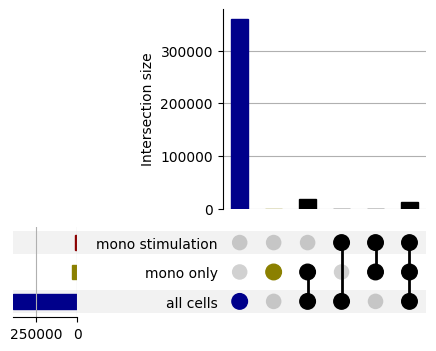

In [42]:
# get the data to make the upset plot
dars_overlaps = from_contents({'all cells' : dars_table['region'].unique(), 'mono only' : mono_only_dars['region'].unique(), 'mono stimulation' : stim_unstim_dars['region'].unique()})
# then make the plot
dars_upset = UpSet(dars_overlaps, subset_size="count")
# get the groups colours
groups_colours = {'all cells' : 'darkblue', 'mono only' : '#8B8000', 'mono stimulation' : 'darkred'}
# and which are present
groups_present = list(groups_colours.keys())
# add colour for each group
for group in groups_present:
    # for the singleton bars that are vertical
    dars_upset.style_subsets(present = [group], absent = [x for x in groups_present if x not in set([group])], facecolor = groups_colours[group])
    # and the bottom left ones
    dars_upset.style_categories([group], bar_facecolor=groups_colours[group])
# set size
figure(figsize=(16, 9), dpi=160)
# show plot
ax_dict = dars_upset.plot()
